Please upload your file: insurance_fraud_data_processed.csv


Saving insurance_fraud_data_processed.csv to insurance_fraud_data_processed (1).csv
Uploaded file: insurance_fraud_data_processed (1).csv

Processed shape: (9249, 43)
Fraud rate: 0.2539 (2348 fraud / 9249)
Completed 20/100
Completed 40/100
Completed 60/100
Completed 80/100
Completed 100/100

Summary Statistics (100 splits with SMOTE):
       Type I Error (FP count)  Type II Error (FN count)  Accuracy   ROC AUC  \
count                 100.0000                  100.0000  100.0000  100.0000   
mean                   34.7400                  453.6700    0.7360    0.5394   
std                     6.1948                    4.0702    0.0040    0.0162   
min                    20.0000                  444.0000    0.7259    0.4933   
25%                    31.0000                  451.0000    0.7330    0.5269   
50%                    34.0000                  454.0000    0.7365    0.5406   
75%                    39.0000                  457.0000    0.7389    0.5515   
max                    

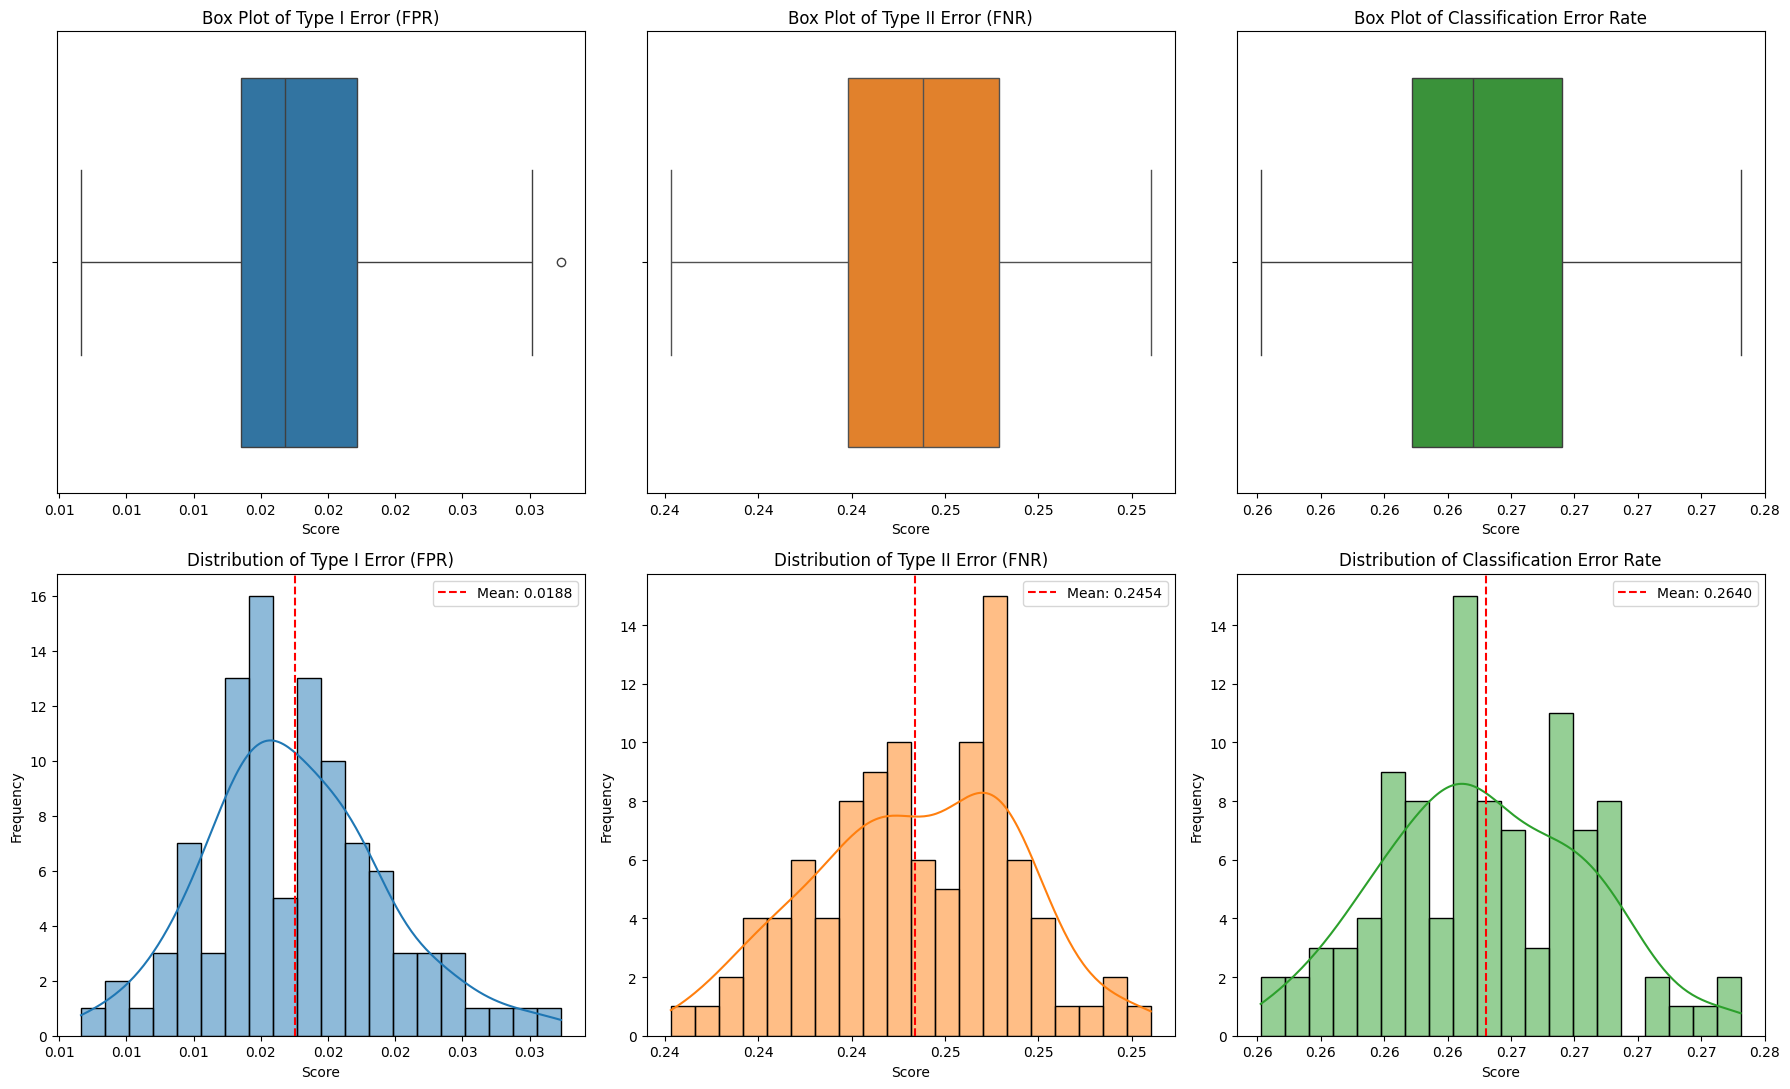

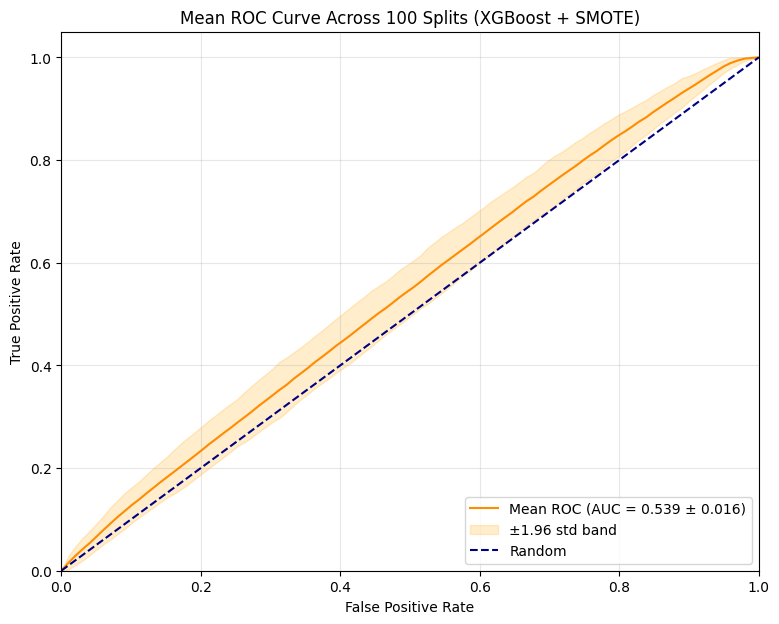

In [2]:
# Insurance Fraud Detection with XGBoost + SMOTE (oversampling on train)

!pip install xgboost imbalanced-learn seaborn --quiet

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, roc_auc_score
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from xgboost import XGBClassifier

# ─── 1. Upload your dataset ─────────────────────────────────────
print("Please upload your file: insurance_fraud_data_processed.csv")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f"Uploaded file: {filename}")

# ─── 2. Load and preprocess ─────────────────────────────────────
df = pd.read_csv(filename)

# Target: Y → 1 (fraud), N → 0 (non-fraud)
df['fraud_reported'] = df['fraud reported'].map({'Y': 1, 'N': 0})
df = df.drop(columns=['fraud reported'])

# Date features
df['claim_date'] = pd.to_datetime(df['claim_date'], errors='coerce')
df['claim_year']  = df['claim_date'].dt.year
df['claim_month'] = df['claim_date'].dt.month
df['claim_day']   = df['claim_date'].dt.day
df = df.drop(columns=['claim_date'])

# One-hot encode categorical columns
cat_cols = df.select_dtypes(include=['object']).columns
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
encoded = encoder.fit_transform(df[cat_cols])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(cat_cols))

# Numerical columns (exclude target)
num_cols = df.select_dtypes(include=['number']).columns.drop('fraud_reported', errors='ignore')

# Final processed DataFrame
df_processed = pd.concat([
    df[num_cols].reset_index(drop=True),
    encoded_df.reset_index(drop=True),
    df['fraud_reported'].reset_index(drop=True)
], axis=1)

X = df_processed.drop(columns=['fraud_reported'])
y = df_processed['fraud_reported']

print(f"\nProcessed shape: {X.shape}")
print(f"Fraud rate: {y.mean():.4f} ({y.sum()} fraud / {len(y)})")

# ─── 3. 100 stratified random splits + SMOTE on train ────────────
type_I_counts = []     # raw FP counts
type_II_counts = []    # raw FN counts
accuracies = []
auc_scores = []
tprs = []              # For mean ROC
mean_fpr = np.linspace(0, 1, 100)

for i in range(100):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=i
    )

    # Apply SMOTE only to training data
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # scale_pos_weight on resampled data
    neg = (y_train_res == 0).sum()
    pos = (y_train_res == 1).sum()
    scale_pos_weight = neg / pos if pos > 0 else 1.0

    model = XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        scale_pos_weight=scale_pos_weight,
        tree_method='hist',
        device='cuda',
        random_state=42,
        eval_metric='aucpr',
        verbosity=0
    )
    model.fit(X_train_res, y_train_res)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    fp = cm[0, 1]          # Type I (FP count)
    fn = cm[1, 0]          # Type II (FN count)
    acc = accuracy_score(y_test, y_pred)

    type_I_counts.append(fp)
    type_II_counts.append(fn)
    accuracies.append(acc)

    # ROC & AUC
    fpr_curve, tpr_curve, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    auc_scores.append(auc)

    interp_tpr = np.interp(mean_fpr, fpr_curve, tpr_curve)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)

    if (i + 1) % 20 == 0:
        print(f"Completed {i+1}/100")

# ─── 4. Results DataFrame with Error Rates ───────────────────────
test_size = int(len(X) * 0.2)   # Number of samples in each test set

results_df = pd.DataFrame({
    'Type I Error (FP count)': type_I_counts,
    'Type II Error (FN count)': type_II_counts,
    'Accuracy': accuracies,
    'ROC AUC': auc_scores
})

# Convert counts to rates
results_df['Type I Error Rate (FPR)'] = results_df['Type I Error (FP count)'] / test_size
results_df['Type II Error Rate (FNR)'] = results_df['Type II Error (FN count)'] / test_size
results_df['Classification Error Rate'] = 1 - results_df['Accuracy']

print("\nSummary Statistics (100 splits with SMOTE):")
print(results_df.describe().round(4))

# ─── 5. 6-panel plots ─────
plt.figure(figsize=(18, 11))

# ===================== TOP ROW: HORIZONTAL BOX PLOTS =====================
# Box Plot of Type I Error (FPR) - Blue
plt.subplot(2, 3, 1)
sns.boxplot(x=results_df['Type I Error Rate (FPR)'], color='#1f77b4')
plt.title('Box Plot of Type I Error (FPR)')
plt.xlabel('Score')
plt.ylabel('')

# Box Plot of Type II Error (FNR) - Orange
plt.subplot(2, 3, 2)
sns.boxplot(x=results_df['Type II Error Rate (FNR)'], color='#ff7f0e')
plt.title('Box Plot of Type II Error (FNR)')
plt.xlabel('Score')
plt.ylabel('')

# Box Plot of Classification Error Rate - Green
plt.subplot(2, 3, 3)
sns.boxplot(x=results_df['Classification Error Rate'], color='#2ca02c')
plt.title('Box Plot of Classification Error Rate')
plt.xlabel('Score')
plt.ylabel('')

# ===================== BOTTOM ROW: HISTOGRAMS + KDE + MEAN LINE =====================
# Distribution of Type I Error (FPR)
plt.subplot(2, 3, 4)
sns.histplot(results_df['Type I Error Rate (FPR)'], bins=20, kde=True, color='#1f77b4')
plt.axvline(results_df['Type I Error Rate (FPR)'].mean(), color='red', linestyle='--',
            label=f'Mean: {results_df["Type I Error Rate (FPR)"].mean():.4f}')
plt.title('Distribution of Type I Error (FPR)')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.legend()

# Distribution of Type II Error (FNR)
plt.subplot(2, 3, 5)
sns.histplot(results_df['Type II Error Rate (FNR)'], bins=20, kde=True, color='#ff7f0e')
plt.axvline(results_df['Type II Error Rate (FNR)'].mean(), color='red', linestyle='--',
            label=f'Mean: {results_df["Type II Error Rate (FNR)"].mean():.4f}')
plt.title('Distribution of Type II Error (FNR)')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.legend()

# Distribution of Classification Error Rate
plt.subplot(2, 3, 6)
sns.histplot(results_df['Classification Error Rate'], bins=20, kde=True, color='#2ca02c')
plt.axvline(results_df['Classification Error Rate'].mean(), color='red', linestyle='--',
            label=f'Mean: {results_df["Classification Error Rate"].mean():.4f}')
plt.title('Distribution of Classification Error Rate')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.legend()

# Force ALL x-axes rounded to    2 decimal places
for ax in plt.gcf().axes:
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))

plt.tight_layout()
plt.show()

# ─── 6. Mean ROC Curve ───────────────────────────────
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = np.mean(auc_scores)
std_auc = np.std(auc_scores)

std_tpr = np.std(tprs, axis=0)
tpr_upper = np.minimum(mean_tpr + 1.96 * std_tpr, 1)
tpr_lower = np.maximum(mean_tpr - 1.96 * std_tpr, 0)

plt.figure(figsize=(9, 7))
plt.plot(mean_fpr, mean_tpr, color='darkorange',
         label=f'Mean ROC (AUC = {mean_auc:.3f} ± {std_auc:.3f})')
plt.fill_between(mean_fpr, tpr_lower, tpr_upper, color='orange', alpha=0.2,
                 label='±1.96 std band')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Mean ROC Curve Across 100 Splits (XGBoost + SMOTE)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()